Loading reference data from _data/verify_icesat2/IS2_MRB_20190101-20190107.parquet...
[Reference Data] Extracting lat/lon from 'geometry' column...
[Reference Data] Date range found: 2019-01-01 18:19:16.045000 to 2019-01-07 18:55:39.733000

Loading test data from _data/icesat2/atl06_benchmark.parquet...
[Test Data] Date range found: 2019-01-01 06:08:00.791249408 to 2019-01-07 18:56:48.813068800

Found 112365 reference points and 381950 test points on 2019-01-01.

⚠️ INCONSISTENCY FOUND: 269585 issues detected.
 - Points missing from Test Data (in Ref only): 0
 - Points missing from Reference Data (in Test only): 269585
 - Points with mismatched 'h_mean' values: 0

Generating map of inconsistent points...


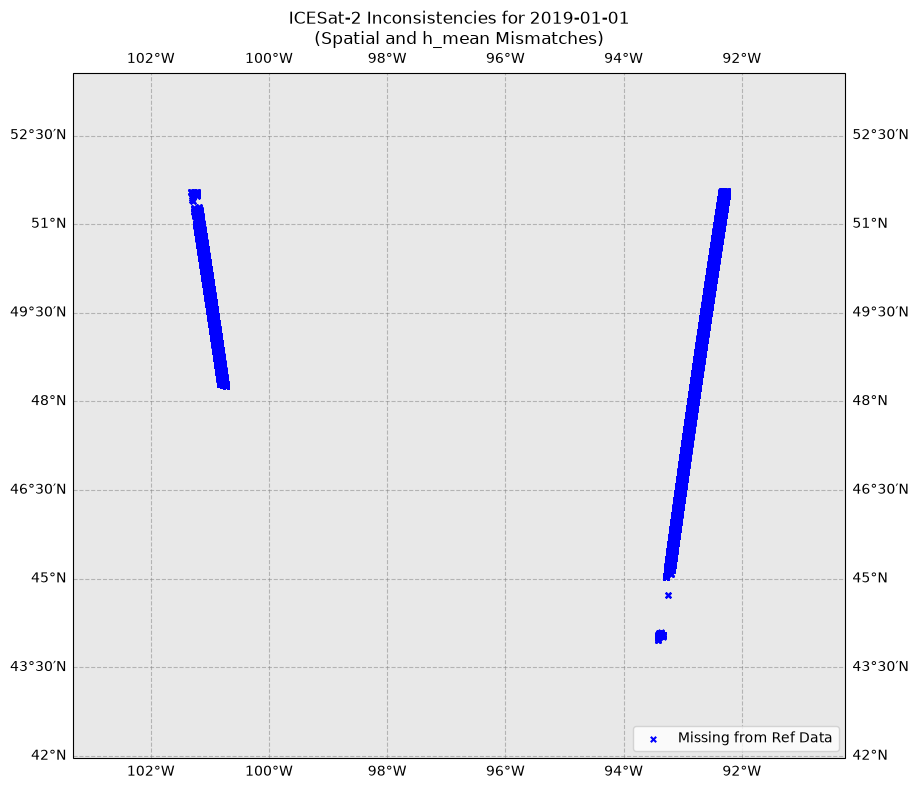

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from shapely import wkb, wkt
from shapely.geometry.base import BaseGeometry

# ==========================================
# 1. Configuration
# ==========================================
REF_FILE = "_data/verify_icesat2/IS2_MRB_20190101-20190107.parquet"
TEST_FILE = "_data/icesat2/atl06_benchmark.parquet"
TARGET_DATE = "2019-01-01"
TOLERANCE = 1e-5  # Sub-millimeter tolerance for h_mean comparison

# ==========================================
# 2. Helper Functions
# ==========================================
def ensure_lat_lon(df, name="Dataset"):
    """
    Checks for 'lat' and 'lon' columns. If missing, attempts to extract 
    them from a 'geometry' column.
    """
    if 'lat' in df.columns and 'lon' in df.columns:
        return df
        
    if 'geometry' not in df.columns:
        raise ValueError(f"{name} lacks both 'lat'/'lon' columns and a 'geometry' column.")
    
    print(f"[{name}] Extracting lat/lon from 'geometry' column...")
    
    # Check if it's already a GeoPandas GeoSeries with .x and .y accessors
    if hasattr(df, 'geometry') and hasattr(df.geometry, 'x'):
        df['lon'] = df.geometry.x
        df['lat'] = df.geometry.y
        return df

    # Otherwise parse Shapely, WKB, or WKT manually
    def extract_coords(geom):
        try:
            if isinstance(geom, BaseGeometry):
                return geom.x, geom.y
            elif isinstance(geom, bytes):
                g = wkb.loads(geom)
                return g.x, g.y
            elif isinstance(geom, str):
                g = wkt.loads(geom)
                return g.x, g.y
        except Exception:
            pass
        return np.nan, np.nan

    coords = df['geometry'].apply(extract_coords)
    df['lon'] = [c[0] for c in coords]
    df['lat'] = [c[1] for c in coords]
    
    return df

def ensure_time_index(df, name="Dataset"):
    """
    Ensures that 'time' is set as the datetime index and is timezone-naive.
    """
    # If 'time' is a standard column, push it to the index
    if 'time' in df.columns:
        df.set_index('time', inplace=True)
    elif df.index.name != 'time':
        # Fallback check if it's named something else like 'datetime'
        if 'datetime' in df.columns:
            df.set_index('datetime', inplace=True)

    # Convert index to datetime
    df.index = pd.to_datetime(df.index)
    
    # Strip timezone information to avoid mismatching with simple date strings
    if df.index.tz is not None:
        df.index = df.index.tz_localize(None)
        
    print(f"[{name}] Date range found: {df.index.min()} to {df.index.max()}")
    return df

# ==========================================
# 3. Load, Parse, and Filter Data
# ==========================================
print(f"Loading reference data from {REF_FILE}...")
df_ref = pd.read_parquet(REF_FILE)
df_ref = ensure_lat_lon(df_ref, "Reference Data")
df_ref = ensure_time_index(df_ref, "Reference Data")

print(f"\nLoading test data from {TEST_FILE}...")
df_test = pd.read_parquet(TEST_FILE)
df_test = ensure_lat_lon(df_test, "Test Data")
df_test = ensure_time_index(df_test, "Test Data")

# Filter by the target date
df_ref_filtered = df_ref[df_ref.index.date == pd.to_datetime(TARGET_DATE).date()].copy()
df_test_filtered = df_test[df_test.index.date == pd.to_datetime(TARGET_DATE).date()].copy()

print(f"\nFound {len(df_ref_filtered)} reference points and {len(df_test_filtered)} test points on {TARGET_DATE}.")

if len(df_ref_filtered) == 0:
    print(f"\n❌ ERROR: Finding 0 points for {TARGET_DATE} in Reference Data.")
    print("Check the printed date range above to ensure the dates in the file match the target date.")
    exit()

# ==========================================
# 4. Compare Data for Consistency
# ==========================================
# Create rounded join keys for spatial matching (6 decimals ~ 11cm accuracy)
df_ref_filtered['lat_round'] = df_ref_filtered['lat'].round(6)
df_ref_filtered['lon_round'] = df_ref_filtered['lon'].round(6)

df_test_filtered['lat_round'] = df_test_filtered['lat'].round(6)
df_test_filtered['lon_round'] = df_test_filtered['lon'].round(6)

cols = ['lat', 'lon', 'h_mean', 'lat_round', 'lon_round']

# Outer merge to align the datasets spatially
merged = pd.merge(
    df_ref_filtered[cols], 
    df_test_filtered[cols], 
    on=['lat_round', 'lon_round'], 
    how='outer', 
    indicator=True,
    suffixes=('_ref', '_test')
)

# Find spatial mismatches
missing_in_test = merged[merged['_merge'] == 'left_only']
missing_in_ref = merged[merged['_merge'] == 'right_only']

# Find h_mean value mismatches for points that matched spatially
both = merged[merged['_merge'] == 'both']
mismatched_h_mean = both[~np.isclose(
    both['h_mean_ref'], 
    both['h_mean_test'], 
    atol=TOLERANCE, 
    equal_nan=True
)]

total_inconsistencies = len(missing_in_test) + len(missing_in_ref) + len(mismatched_h_mean)

if total_inconsistencies == 0:
    print("\n✅ SUCCESS: The datasets are perfectly consistent for 2019-01-01.")
    print("All points match spatially and all h_mean values are identical.")
else:
    print(f"\n⚠️ INCONSISTENCY FOUND: {total_inconsistencies} issues detected.")
    print(f" - Points missing from Test Data (in Ref only): {len(missing_in_test)}")
    print(f" - Points missing from Reference Data (in Test only): {len(missing_in_ref)}")
    print(f" - Points with mismatched 'h_mean' values: {len(mismatched_h_mean)}")

    # ==========================================
    # 5. Plot Inconsistencies on a Map
    # ==========================================
    print("\nGenerating map of inconsistent points...")
    
    fig = plt.figure(figsize=(10, 8))
    ax = plt.axes(projection=ccrs.PlateCarree())
    
    ax.add_feature(cfeature.LAND, facecolor='lightgray', alpha=0.5)
    ax.add_feature(cfeature.OCEAN, facecolor='lightblue', alpha=0.5)
    ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
    ax.gridlines(draw_labels=True, dms=True, color='gray', linestyle='--', alpha=0.5)

    lons_extent, lats_extent = [], []

    # Plot points missing from Test
    if not missing_in_test.empty:
        ax.scatter(missing_in_test['lon_ref'], missing_in_test['lat_ref'], 
                   color='red', s=15, label='Missing from Test Data', transform=ccrs.PlateCarree(), zorder=5)
        lons_extent.extend(missing_in_test['lon_ref'].tolist())
        lats_extent.extend(missing_in_test['lat_ref'].tolist())

    # Plot points missing from Reference
    if not missing_in_ref.empty:
        ax.scatter(missing_in_ref['lon_test'], missing_in_ref['lat_test'], 
                   color='blue', marker='x', s=15, label='Missing from Ref Data', transform=ccrs.PlateCarree(), zorder=6)
        lons_extent.extend(missing_in_ref['lon_test'].tolist())
        lats_extent.extend(missing_in_ref['lat_test'].tolist())

    # Plot points with mismatched h_mean
    if not mismatched_h_mean.empty:
        ax.scatter(mismatched_h_mean['lon_ref'], mismatched_h_mean['lat_ref'], 
                   color='orange', marker='^', s=25, label='Mismatched h_mean', transform=ccrs.PlateCarree(), zorder=7)
        lons_extent.extend(mismatched_h_mean['lon_ref'].tolist())
        lats_extent.extend(mismatched_h_mean['lat_ref'].tolist())

    plt.title(f'ICESat-2 Inconsistencies for {TARGET_DATE}\n(Spatial and h_mean Mismatches)')
    plt.legend(loc='lower right')
    
    # Zoom into the problem areas if they exist
    if lons_extent and lats_extent:
        lon_min, lon_max = min(lons_extent) - 2, max(lons_extent) + 2
        lat_min, lat_max = min(lats_extent) - 2, max(lats_extent) + 2
        ax.set_extent([lon_min, lon_max, lat_min, lat_max], crs=ccrs.PlateCarree())

    plt.tight_layout()
    plt.show()

Loading reference data from _data/verify_icesat2/IS2_MRB_20190101-20190107.parquet...
[Reference Data] Extracting lat/lon from 'geometry' column...
[Reference Data] Date range found: 2019-01-01 18:19:16.045000 to 2019-01-07 18:55:39.733000

Loading test data from _data/icesat2/atl06_benchmark.parquet...
[Test Data] Date range found: 2019-01-01 06:08:00.791249408 to 2019-01-07 18:56:48.813068800

Found 112365 reference points and 381950 test points on 2019-01-01.

=== COMPARISON RESULTS ===
✅ Perfectly matched points: 112365
⚠️ INCONSISTENCY FOUND: 269585 issues detected.
 - Points missing from Test Data (in Ref only): 0
 - Points missing from Reference Data (in Test only): 269585
 - Points with mismatched 'h_mean' values: 0

Generating map of inconsistent points...
Generating map of perfectly matching points...


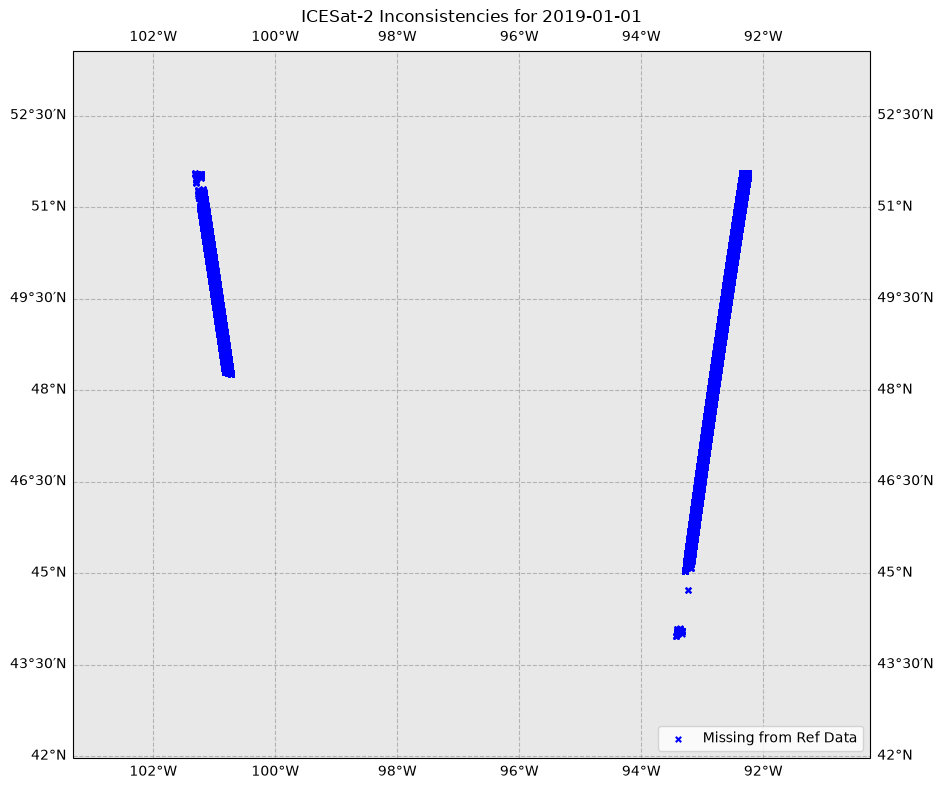

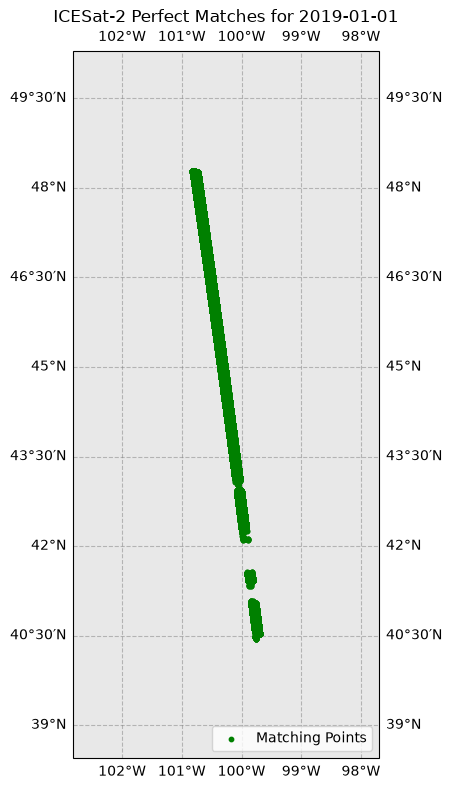

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from shapely import wkb, wkt
from shapely.geometry.base import BaseGeometry

# ==========================================
# 1. Configuration
# ==========================================
REF_FILE = "_data/verify_icesat2/IS2_MRB_20190101-20190107.parquet"
TEST_FILE = "_data/icesat2/atl06_benchmark.parquet"
TARGET_DATE = "2019-01-01"
TOLERANCE = 1e-5  # Sub-millimeter tolerance for h_mean comparison

# ==========================================
# 2. Helper Functions
# ==========================================
def ensure_lat_lon(df, name="Dataset"):
    """
    Checks for 'lat' and 'lon' columns. If missing, attempts to extract 
    them from a 'geometry' column.
    """
    if 'lat' in df.columns and 'lon' in df.columns:
        return df
        
    if 'geometry' not in df.columns:
        raise ValueError(f"{name} lacks both 'lat'/'lon' columns and a 'geometry' column.")
    
    print(f"[{name}] Extracting lat/lon from 'geometry' column...")
    
    if hasattr(df, 'geometry') and hasattr(df.geometry, 'x'):
        df['lon'] = df.geometry.x
        df['lat'] = df.geometry.y
        return df

    def extract_coords(geom):
        try:
            if isinstance(geom, BaseGeometry):
                return geom.x, geom.y
            elif isinstance(geom, bytes):
                g = wkb.loads(geom)
                return g.x, g.y
            elif isinstance(geom, str):
                g = wkt.loads(geom)
                return g.x, g.y
        except Exception:
            pass
        return np.nan, np.nan

    coords = df['geometry'].apply(extract_coords)
    df['lon'] = [c[0] for c in coords]
    df['lat'] = [c[1] for c in coords]
    
    return df

def ensure_time_index(df, name="Dataset"):
    """
    Ensures that 'time' is set as the datetime index and is timezone-naive.
    """
    if 'time' in df.columns:
        df.set_index('time', inplace=True)
    elif df.index.name != 'time':
        if 'datetime' in df.columns:
            df.set_index('datetime', inplace=True)

    df.index = pd.to_datetime(df.index)
    
    if df.index.tz is not None:
        df.index = df.index.tz_localize(None)
        
    print(f"[{name}] Date range found: {df.index.min()} to {df.index.max()}")
    return df

# ==========================================
# 3. Load, Parse, and Filter Data
# ==========================================
print(f"Loading reference data from {REF_FILE}...")
df_ref = pd.read_parquet(REF_FILE)
df_ref = ensure_lat_lon(df_ref, "Reference Data")
df_ref = ensure_time_index(df_ref, "Reference Data")

print(f"\nLoading test data from {TEST_FILE}...")
df_test = pd.read_parquet(TEST_FILE)
df_test = ensure_lat_lon(df_test, "Test Data")
df_test = ensure_time_index(df_test, "Test Data")

df_ref_filtered = df_ref[df_ref.index.date == pd.to_datetime(TARGET_DATE).date()].copy()
df_test_filtered = df_test[df_test.index.date == pd.to_datetime(TARGET_DATE).date()].copy()

print(f"\nFound {len(df_ref_filtered)} reference points and {len(df_test_filtered)} test points on {TARGET_DATE}.")

if len(df_ref_filtered) == 0:
    print(f"\n❌ ERROR: Finding 0 points for {TARGET_DATE} in Reference Data.")
    print("Check the printed date range above to ensure the dates in the file match the target date.")
    exit()

# ==========================================
# 4. Compare Data for Consistency
# ==========================================
df_ref_filtered['lat_round'] = df_ref_filtered['lat'].round(6)
df_ref_filtered['lon_round'] = df_ref_filtered['lon'].round(6)

df_test_filtered['lat_round'] = df_test_filtered['lat'].round(6)
df_test_filtered['lon_round'] = df_test_filtered['lon'].round(6)

cols = ['lat', 'lon', 'h_mean', 'lat_round', 'lon_round']

merged = pd.merge(
    df_ref_filtered[cols], 
    df_test_filtered[cols], 
    on=['lat_round', 'lon_round'], 
    how='outer', 
    indicator=True,
    suffixes=('_ref', '_test')
)

missing_in_test = merged[merged['_merge'] == 'left_only']
missing_in_ref = merged[merged['_merge'] == 'right_only']
both = merged[merged['_merge'] == 'both']

# Identify exact h_mean matches vs mismatches
is_match_mask = np.isclose(
    both['h_mean_ref'], 
    both['h_mean_test'], 
    atol=TOLERANCE, 
    equal_nan=True
)

matched_perfectly = both[is_match_mask]
mismatched_h_mean = both[~is_match_mask]

total_inconsistencies = len(missing_in_test) + len(missing_in_ref) + len(mismatched_h_mean)

print(f"\n=== COMPARISON RESULTS ===")
print(f"✅ Perfectly matched points: {len(matched_perfectly)}")

if total_inconsistencies == 0:
    print("✅ SUCCESS: The datasets are perfectly consistent for 2019-01-01.")
else:
    print(f"⚠️ INCONSISTENCY FOUND: {total_inconsistencies} issues detected.")
    print(f" - Points missing from Test Data (in Ref only): {len(missing_in_test)}")
    print(f" - Points missing from Reference Data (in Test only): {len(missing_in_ref)}")
    print(f" - Points with mismatched 'h_mean' values: {len(mismatched_h_mean)}")

# ==========================================
# 5. Map 1: Plot Inconsistencies (If any)
# ==========================================
if total_inconsistencies > 0:
    print("\nGenerating map of inconsistent points...")
    fig1 = plt.figure(figsize=(10, 8))
    ax1 = plt.axes(projection=ccrs.PlateCarree())
    
    ax1.add_feature(cfeature.LAND, facecolor='lightgray', alpha=0.5)
    ax1.add_feature(cfeature.OCEAN, facecolor='lightblue', alpha=0.5)
    ax1.add_feature(cfeature.COASTLINE, linewidth=0.5)
    ax1.gridlines(draw_labels=True, dms=True, color='gray', linestyle='--', alpha=0.5)

    lons_extent, lats_extent = [], []

    if not missing_in_test.empty:
        ax1.scatter(missing_in_test['lon_ref'], missing_in_test['lat_ref'], 
                   color='red', s=15, label='Missing from Test Data', transform=ccrs.PlateCarree(), zorder=5)
        lons_extent.extend(missing_in_test['lon_ref'].tolist())
        lats_extent.extend(missing_in_test['lat_ref'].tolist())

    if not missing_in_ref.empty:
        ax1.scatter(missing_in_ref['lon_test'], missing_in_ref['lat_test'], 
                   color='blue', marker='x', s=15, label='Missing from Ref Data', transform=ccrs.PlateCarree(), zorder=6)
        lons_extent.extend(missing_in_ref['lon_test'].tolist())
        lats_extent.extend(missing_in_ref['lat_test'].tolist())

    if not mismatched_h_mean.empty:
        ax1.scatter(mismatched_h_mean['lon_ref'], mismatched_h_mean['lat_ref'], 
                   color='orange', marker='^', s=25, label='Mismatched h_mean', transform=ccrs.PlateCarree(), zorder=7)
        lons_extent.extend(mismatched_h_mean['lon_ref'].tolist())
        lats_extent.extend(mismatched_h_mean['lat_ref'].tolist())

    plt.title(f'ICESat-2 Inconsistencies for {TARGET_DATE}')
    plt.legend(loc='lower right')
    
    if lons_extent and lats_extent:
        lon_min, lon_max = min(lons_extent) - 2, max(lons_extent) + 2
        lat_min, lat_max = min(lats_extent) - 2, max(lats_extent) + 2
        ax1.set_extent([lon_min, lon_max, lat_min, lat_max], crs=ccrs.PlateCarree())

    plt.tight_layout()

# ==========================================
# 6. Map 2: Plot Matches
# ==========================================
if not matched_perfectly.empty:
    print(f"Generating map of perfectly matching points...")
    fig2 = plt.figure(figsize=(10, 8))
    ax2 = plt.axes(projection=ccrs.PlateCarree())
    
    ax2.add_feature(cfeature.LAND, facecolor='lightgray', alpha=0.5)
    ax2.add_feature(cfeature.OCEAN, facecolor='lightblue', alpha=0.5)
    ax2.add_feature(cfeature.COASTLINE, linewidth=0.5)
    ax2.gridlines(draw_labels=True, dms=True, color='gray', linestyle='--', alpha=0.5)

    # Plot matched points in Green
    ax2.scatter(
        matched_perfectly['lon_ref'], matched_perfectly['lat_ref'], 
        color='green', s=10, label='Matching Points', transform=ccrs.PlateCarree(), zorder=5
    )
    
    plt.title(f'ICESat-2 Perfect Matches for {TARGET_DATE}')
    plt.legend(loc='lower right')
    
    # Zoom to the extent of matched points
    lon_min, lon_max = matched_perfectly['lon_ref'].min() - 2, matched_perfectly['lon_ref'].max() + 2
    lat_min, lat_max = matched_perfectly['lat_ref'].min() - 2, matched_perfectly['lat_ref'].max() + 2
    
    # Make sure we don't zoom out past world boundaries
    lon_min, lon_max = max(lon_min, -180), min(lon_max, 180)
    lat_min, lat_max = max(lat_min, -90), min(lat_max, 90)
    
    ax2.set_extent([lon_min, lon_max, lat_min, lat_max], crs=ccrs.PlateCarree())
    plt.tight_layout()

# Display plots (this will pause the script until windows are closed)
plt.show()